# 🚕 EDA: NYC Taxi & Weather Analysis

Notebook ini adalah pusat analisis eksploratif untuk proyek RDV-Taxi. Di sini kita menggabungkan perspektif **Data Engineering** (kualitas data)

---

### 🎯 Tujuan Analisis:


## 1. Setup & Environment

In [16]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

# Konfigurasi Visualisasi
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Koneksi ke Database
DB_PATH = os.path.join("..", "data", "final", "tlc.duckdb")
con = duckdb.connect(DB_PATH, read_only=True)
print(f"✅ Connected to: {os.path.abspath(DB_PATH)}")

✅ Connected to: c:\Users\ASUS\Documents\!KULIAH S1\Semester 6\Rekayasa Data Visualisasi\Project\RDV-Taxi\data\final\tlc.duckdb


## 2. Data Engineering Audit (Data Quality)
Langkah pertama DE adalah mengecek apakah pipeline pembersihan data bekerja dengan baik.

## 2A. Data Quality Audit untuk Data Engineer

Bagian ini menilai kesehatan data dari sisi pipeline: kelengkapan tabel, null rate, duplicate rate, coverage join, dan distribusi batch.

Table health summary


,table,rows,columns,duplicate_rows,duplicate_rate,null_cells,null_cell_rate
3,dim_location,263,10,0,0.000000e+00,8,0.003042
4,dim_time,181,12,0,0.000000e+00,0,0.000000
5,dim_weather,181,12,0,0.000000e+00,0,0.000000
2,fact_trips,18112530,36,0,0.000000e+00,373236,0.000572
1,tlc_cleaned,18112530,25,1,5.521040e-08,72450120,0.160000
0,tlc_raw,24083384,20,0,0.000000e+00,27093005,0.056248



Top null columns - tlc_raw


,column_name,null_rows,null_rate
3,passenger_count,5418601,0.224993
17,congestion_surcharge,5418601,0.224993
6,store_and_fwd_flag,5418601,0.224993
5,RatecodeID,5418601,0.224993
18,Airport_fee,5418601,0.224993
2,tpep_dropoff_datetime,0,0.000000
0,VendorID,0,0.000000
1,tpep_pickup_datetime,0,0.000000



Top null columns - tlc_cleaned


...

,column_name,null_rows,null_rate
0,time_key,0,0.0
1,date_key,0,0.0
2,date_actual,0,0.0
3,year,0,0.0
4,month,0,0.0
5,day,0,0.0
6,quarter,0,0.0
7,week_of_year,0,0.0



Top null columns - dim_weather


,column_name,null_rows,null_rate
0,weather_key,0,0.0
1,date_key,0,0.0
2,temperature_2m,0,0.0
3,relative_humidity_2m,0,0.0
4,precipitation,0,0.0
5,wind_speed_10m,0,0.0
6,wind_direction_10m,0,0.0
7,weather_code,0,0.0



Referential integrity to dim_location


,join_key,total_rows,unmatched_rows,match_rate
0,pickup_location_key,18112530,0,1.0
1,dropoff_location_key,18112530,0,1.0


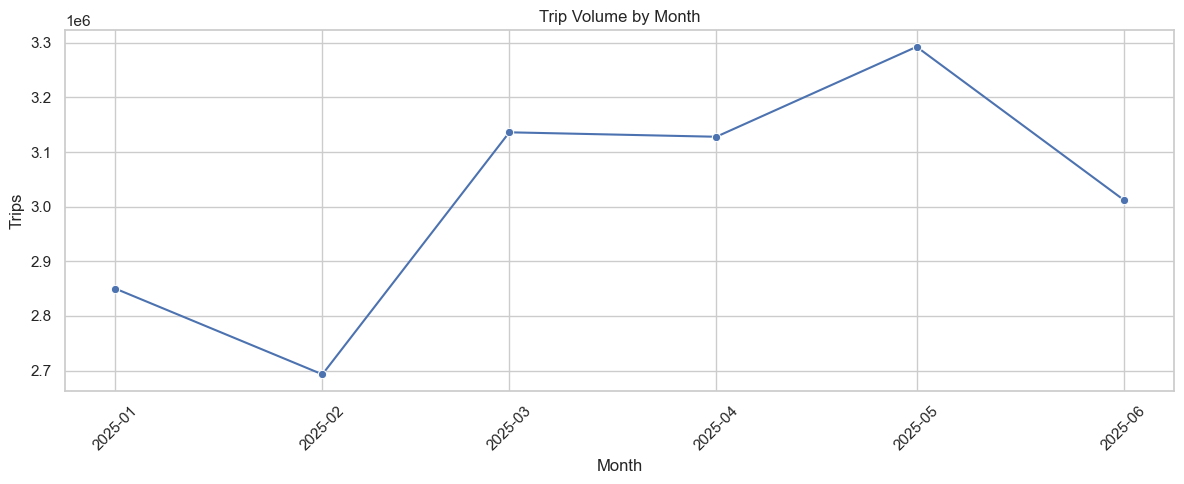

In [20]:
from IPython.display import display

def qname(identifier):
    return '"' + identifier.replace('"', '""') + '"'


def get_connection():
    global con
    try:
        con.execute("SELECT 1")
    except Exception:
        con = duckdb.connect(DB_PATH, read_only=True)
    return con


def get_table_columns(table_name):
    return get_connection().execute(f"PRAGMA table_info('{table_name}')").df()["name"].tolist()


def exact_duplicate_rows(table_name, columns):
    if not columns:
        return 0

    conn = get_connection()
    hash_expr = "md5(concat_ws('||', " + ", ".join(
        [f"coalesce(cast({qname(column)} as VARCHAR), '∅')" for column in columns]
    ) + "))"

    return int(
        conn.execute(
            f"""
            SELECT COUNT(*) - COUNT(DISTINCT row_hash) AS duplicate_rows
            FROM (
                SELECT {hash_expr} AS row_hash
                FROM {qname(table_name)}
            ) t
            """
        ).fetchone()[0]
    )


def null_detail(table_name, columns):
    if not columns:
        return pd.DataFrame(columns=["column_name", "null_rows", "null_rate"])

    conn = get_connection()
    row_count = int(conn.execute(f"SELECT COUNT(*) FROM {qname(table_name)}").fetchone()[0])
    select_clause = ", ".join(
        [f"SUM(CASE WHEN {qname(column)} IS NULL THEN 1 ELSE 0 END) AS {qname(column + '_nulls')}" for column in columns]
    )
    null_counts = conn.execute(f"SELECT {select_clause} FROM {qname(table_name)}").fetchone()

    rows = []
    for column, null_count in zip(columns, null_counts):
        rows.append(
            {
                "column_name": column,
                "null_rows": int(null_count),
                "null_rate": (float(null_count) / row_count) if row_count else 0.0,
            }
        )
    return pd.DataFrame(rows)


conn = get_connection()
existing_tables = set(conn.execute("SHOW TABLES").df()["name"].tolist())
key_tables = ["tlc_raw", "tlc_cleaned", "fact_trips", "dim_location", "dim_time", "dim_weather"]

quality_rows = []
null_by_table = {}

for table_name in key_tables:
    if table_name not in existing_tables:
        continue

    columns = get_table_columns(table_name)
    row_count = int(conn.execute(f"SELECT COUNT(*) FROM {qname(table_name)}").fetchone()[0])
    duplicate_rows = exact_duplicate_rows(table_name, columns)
    null_df = null_detail(table_name, columns)
    total_null_cells = int(null_df["null_rows"].sum()) if not null_df.empty else 0
    total_cells = row_count * len(columns)

    quality_rows.append(
        {
            "table": table_name,
            "rows": row_count,
            "columns": len(columns),
            "duplicate_rows": duplicate_rows,
            "duplicate_rate": (duplicate_rows / row_count) if row_count else 0.0,
            "null_cells": total_null_cells,
            "null_cell_rate": (total_null_cells / total_cells) if total_cells else 0.0,
        }
    )

    if not null_df.empty:
        null_by_table[table_name] = null_df.sort_values("null_rate", ascending=False).head(8)

quality_df = pd.DataFrame(quality_rows).sort_values("table")
print("Table health summary")
display(quality_df)

for table_name, detail_df in null_by_table.items():
    print(f"\nTop null columns - {table_name}")
    display(detail_df)

if "fact_trips" in existing_tables and "dim_location" in existing_tables:
    fact_columns = set(get_table_columns("fact_trips"))
    dim_location_columns = set(get_table_columns("dim_location"))
    join_rows = []

    for key_column in ["pickup_location_key", "dropoff_location_key"]:
        if key_column in fact_columns and "location_key" in dim_location_columns:
            join_result = conn.execute(
                f"""
                SELECT
                    COUNT(*) AS total_rows,
                    SUM(CASE WHEN l.location_key IS NULL THEN 1 ELSE 0 END) AS unmatched_rows
                FROM fact_trips f
                LEFT JOIN dim_location l
                  ON f.{qname(key_column)} = l.location_key
                """
            ).fetchone()
            total_rows = int(join_result[0])
            unmatched_rows = int(join_result[1] or 0)
            join_rows.append(
                {
                    "join_key": key_column,
                    "total_rows": total_rows,
                    "unmatched_rows": unmatched_rows,
                    "match_rate": 1.0 - (unmatched_rows / total_rows if total_rows else 0.0),
                }
            )

    if join_rows:
        print("\nReferential integrity to dim_location")
        display(pd.DataFrame(join_rows))

fact_trip_columns = set(get_table_columns("fact_trips")) if "fact_trips" in existing_tables else set()
time_column_candidates = [
    "pickup_datetime",
    "lpep_pickup_datetime",
    "tpep_pickup_datetime",
    "trip_start_timestamp",
    "trip_start_time",
]
time_column = next((column for column in time_column_candidates if column in fact_trip_columns), None)

if time_column:
    monthly_trips = conn.execute(
        f"""
        SELECT date_trunc('month', {qname(time_column)}) AS month_start, COUNT(*) AS trips
        FROM fact_trips
        GROUP BY 1
        ORDER BY 1
        """
    ).df()

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=monthly_trips, x="month_start", y="trips", marker="o")
    plt.title("Trip Volume by Month")
    plt.xlabel("Month")
    plt.ylabel("Trips")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


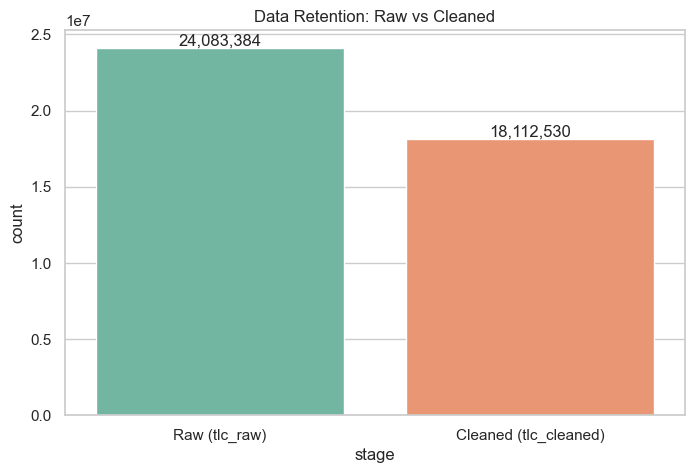

In [21]:
# Bandingkan jumlah data sebelum dan sesudah dibersihkan
dq_query = """
SELECT 
    'Raw (tlc_raw)' as stage, COUNT(*) as count FROM tlc_raw
UNION ALL
SELECT 
    'Cleaned (tlc_cleaned)' as stage, COUNT(*) as count FROM tlc_cleaned
"""
dq_df = con.execute(dq_query).df()

plt.figure(figsize=(8, 5))
sns.barplot(data=dq_df, x='stage', y='count', palette='Set2')
plt.title('Data Retention: Raw vs Cleaned')
for i, v in enumerate(dq_df['count']):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.show()

## 3. Trip Metrics Distribution
Menganalisis statistik utama seperti tarif, jarak, dan durasi.

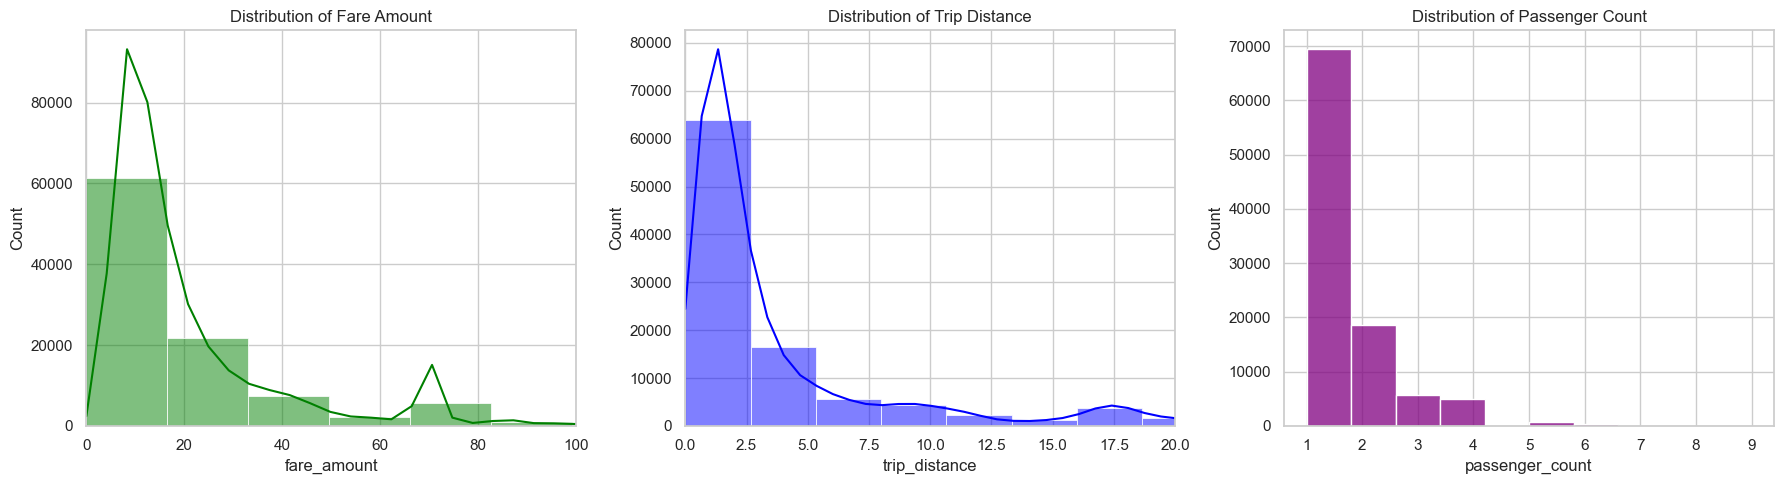

In [22]:
# Ambil data sample untuk visualisasi cepat
df_trips = con.execute("SELECT * FROM fact_trips LIMIT 100000").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_trips['fare_amount'], bins=50, ax=axes[0], color='green', kde=True)
axes[0].set_title('Distribution of Fare Amount')
axes[0].set_xlim(0, 100)

sns.histplot(df_trips['trip_distance'], bins=50, ax=axes[1], color='blue', kde=True)
axes[1].set_title('Distribution of Trip Distance')
axes[1].set_xlim(0, 20)

sns.histplot(df_trips['passenger_count'], bins=10, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Passenger Count')

plt.tight_layout()
plt.show()

## 7. Kesimpulan

Dari sudut pandang data engineer, pipeline ini sudah cukup sehat karena fact dan dimension utama saling terhubung dengan baik, duplicate hampir nol, dan referential integrity ke `dim_location` mencapai 100%. Masalah yang masih perlu diawasi adalah null pada koordinat di `tlc_cleaned`, null kecil di `fact_trips`, serta koordinat kosong di beberapa baris `dim_location`. Jadi, fokus perbaikan berikutnya bukan ke analisis bisnis lagi, tetapi ke validasi kualitas data di tahap cleaning dan enrichment agar downstream model dan dashboard lebih stabil.